### Import

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


In [2]:
img = cv.imread("output/camera.png", cv.IMREAD_GRAYSCALE)


In [3]:
_, binary = cv.threshold(img, 120, 255, cv.THRESH_BINARY)

kernel_sizes = [2, 3, 5]
results = []


In [4]:
for k in kernel_sizes:
    kernel = cv.getStructuringElement(cv.MORPH_RECT, (k, k))
    
    erode_binary = cv.erode(binary, kernel, iterations=1)
    dilate_binary = cv.dilate(binary, kernel, iterations=1)
    opening_binary = cv.morphologyEx(binary, cv.MORPH_OPEN, kernel)
    closing_binary = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel)
    
    results.append((erode_binary, dilate_binary, opening_binary, closing_binary))



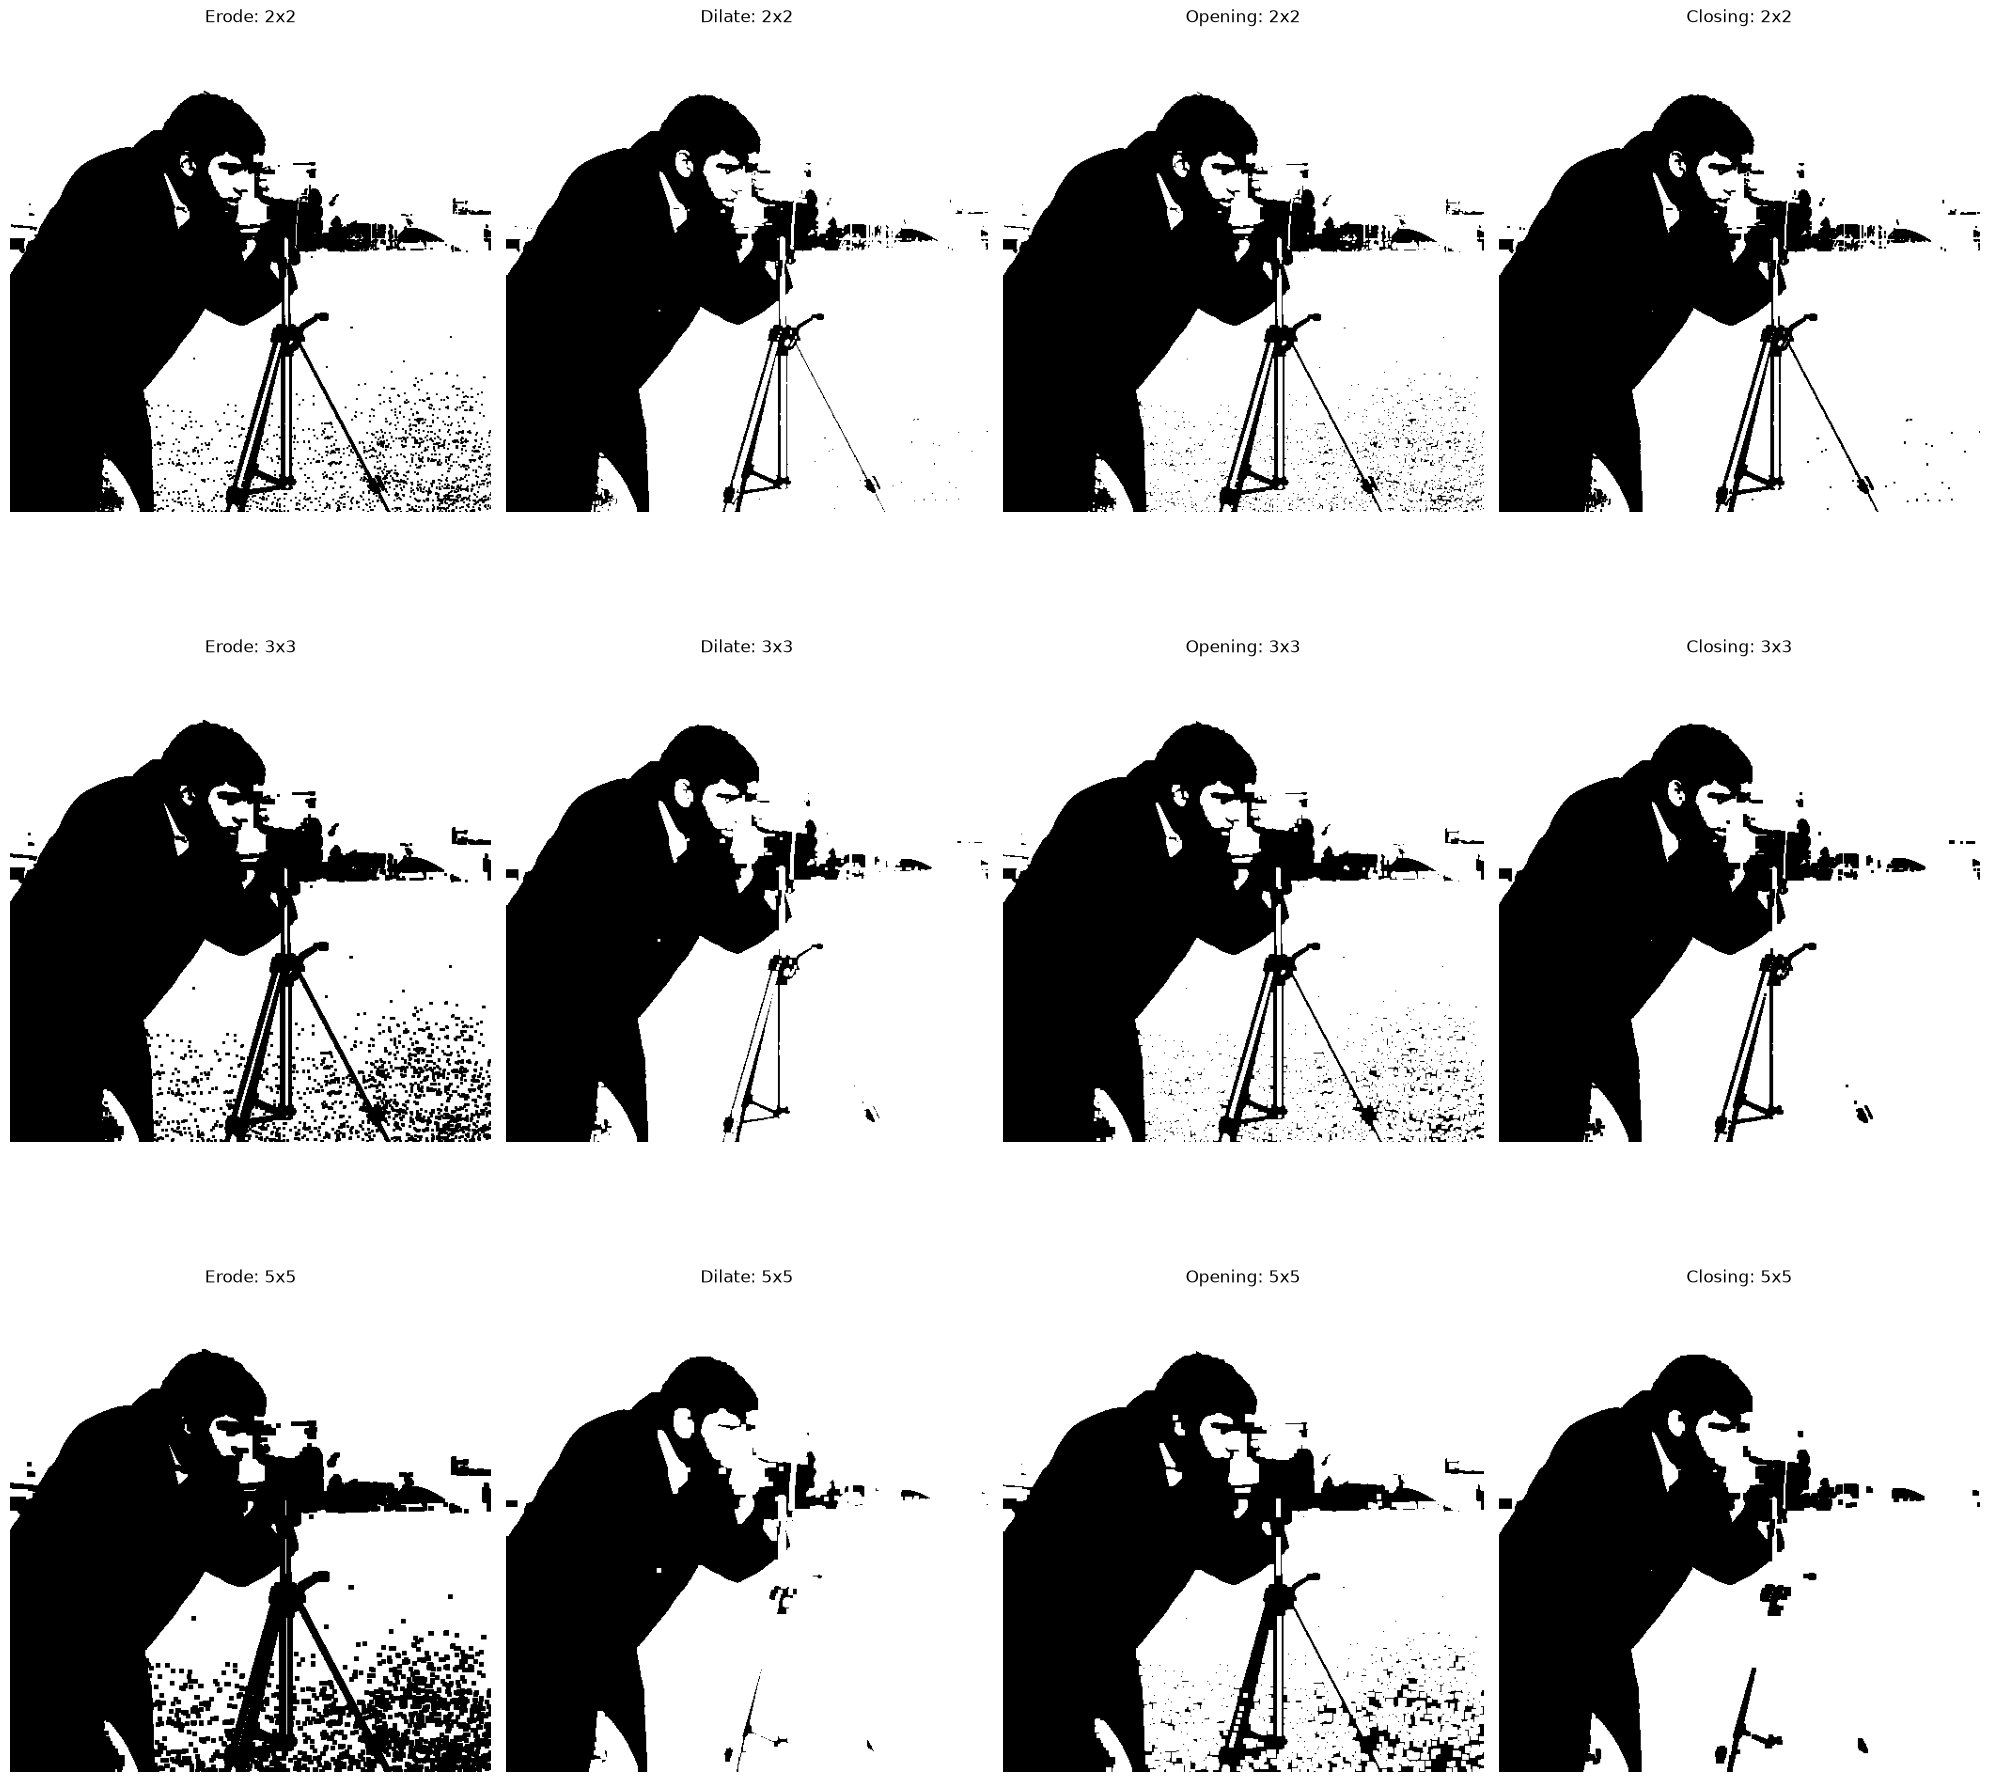

In [5]:
plt.figure(figsize=(20,20))

for i in range(3):
    plt.subplot(3, 4, 4*i+1)
    plt.imshow(results[i][0], cmap='gray')
    plt.title(f"Erode: {kernel_sizes[i]}x{kernel_sizes[i]}")
    plt.axis('off')

    plt.subplot(3, 4, 4*i+2)
    plt.imshow(results[i][1], cmap='gray')
    plt.title(f"Dilate: {kernel_sizes[i]}x{kernel_sizes[i]}")
    plt.axis('off')
    
    plt.subplot(3, 4, 4*i+3)
    plt.imshow(results[i][2], cmap='gray')
    plt.title(f"Opening: {kernel_sizes[i]}x{kernel_sizes[i]}")
    plt.axis('off')

    plt.subplot(3, 4, 4*i+4)
    plt.imshow(results[i][3], cmap='gray')
    plt.title(f"Closing: {kernel_sizes[i]}x{kernel_sizes[i]}")
    plt.axis('off')
    
plt.tight_layout()
plt.savefig("output/5_morphology.png")
plt.show()
    